In [72]:
import json
from io import StringIO
from pathlib import Path
import pandas as pd


def load_highest_result_log(path="../../data/round_2/result_logs/301044.log"):
    path = Path(path)

    with path.open("r", encoding="utf-8") as f:
        raw = json.load(f)

    print(raw.keys())  # helps confirm field names

    # IMC logs often store the activity table under "activitiesLog"
    # but sometimes the structure can differ, so we check safely.
    activities_text = raw.get("activitiesLog")

    if activities_text is None:
        raise KeyError(f"No 'activitiesLog' key found. Available keys: {list(raw.keys())}")

    activities = pd.read_csv(
        StringIO(activities_text),
        sep=";",
        na_values=["", "null", "None"],
    )

    trades = pd.DataFrame(raw.get("tradeHistory", []))
    sandbox = pd.DataFrame(raw.get("sandboxLogs", []))

    return {
        "submission_id": raw.get("submissionId"),
        "activities": activities,
        "trades": trades,
        "sandbox": sandbox,
        "raw": raw,
    }


parsed = load_highest_result_log()
activities_df = parsed["activities"]
trades_df = parsed["trades"]
sandbox_df = parsed["sandbox"]

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])


In [73]:
root_prices = activities_df[activities_df["product"] == "INTARIAN_PEPPER_ROOT"]
root_trades = trades_df[trades_df["symbol"] == "INTARIAN_PEPPER_ROOT"]

ash_prices = activities_df[activities_df["product"] == "ASH_COATED_OSMIUM"]
ash_trades = trades_df[trades_df["symbol"] == "ASH_COATED_OSMIUM"]

ash_buys = ash_trades[ash_trades["buyer"] == "SUBMISSION"]
ash_sells = ash_trades[ash_trades["seller"] == "SUBMISSION"]

root_buys = root_trades[root_trades["buyer"] == "SUBMISSION"]
root_sells = root_trades[root_trades["seller"] == "SUBMISSION"]

In [74]:
root_prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,1,0,INTARIAN_PEPPER_ROOT,12993.0,9.0,12990.0,25.0,NaN,NaN,13007.0,9.0,NaN,NaN,NaN,NaN,13000.0,0.000
2,1,100,INTARIAN_PEPPER_ROOT,12993.0,8.0,12990.0,22.0,NaN,NaN,13007.0,8.0,13010.0,22.0,NaN,NaN,13000.0,0.000
5,1,200,INTARIAN_PEPPER_ROOT,12993.0,9.0,12990.0,22.0,NaN,NaN,13007.0,9.0,13010.0,22.0,NaN,NaN,13000.0,0.000
6,1,300,INTARIAN_PEPPER_ROOT,12993.0,8.0,12990.0,23.0,NaN,NaN,13007.0,8.0,13011.0,23.0,NaN,NaN,13000.0,0.000
8,1,400,INTARIAN_PEPPER_ROOT,12993.0,10.0,12990.0,15.0,NaN,NaN,13011.0,15.0,NaN,NaN,NaN,NaN,13002.0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,1,99500,INTARIAN_PEPPER_ROOT,13092.0,12.0,13089.0,18.0,NaN,NaN,13107.0,12.0,13110.0,18.0,NaN,NaN,13099.5,6190.000
1993,1,99600,INTARIAN_PEPPER_ROOT,13093.0,12.0,13089.0,16.0,NaN,NaN,13107.0,12.0,13110.0,16.0,NaN,NaN,13100.0,6197.750
1994,1,99700,INTARIAN_PEPPER_ROOT,13093.0,12.0,13089.0,21.0,NaN,NaN,13107.0,12.0,13110.0,21.0,NaN,NaN,13100.0,6205.625
1996,1,99800,INTARIAN_PEPPER_ROOT,13093.0,11.0,NaN,NaN,NaN,NaN,13107.0,11.0,13110.0,18.0,NaN,NaN,13100.0,6213.375


In [75]:
root_prices["mid_price"] = (root_prices["bid_price_1"] + root_prices["ask_price_1"])/2

In [76]:
import pandas as pd
import numpy as np

ROOT_FAST_ALPHA = 0.2
ROOT_SLOW_ALPHA = 0.12
ROOT_MICRO_ALPHA = 0.8
ROOT_TREND_WEIGHT = 0.95
ROOT_MAX_TREND_SHIFT = 6.0
ROOT_REVERSION_WEIGHT = 0.6
ROOT_MAX_REVERSION_SHIFT = 3

def clamp(value, lower, upper):
    return max(lower, min(upper, value))

def ema(history, alpha):
    value = history[0]
    for price in history[1:]:
        value = (1 - alpha) * value + alpha * price
    return value

def fair_value_from_history(history, best_bid, best_ask, bid_volume, ask_volume):
    slow_ema = ema(history, ROOT_SLOW_ALPHA)
    fast_ema = ema(history, ROOT_FAST_ALPHA)
    fair_value = 0.55 * fast_ema + 0.45 * slow_ema

    #fair_value = history[-1]
    if pd.notna(best_bid) and pd.notna(best_ask) and best_bid < best_ask and pd.notna(bid_volume) and pd.notna(ask_volume):
        total = bid_volume + ask_volume
        if total > 0:
            micro_price = (best_bid * ask_volume + best_ask * bid_volume) / total
            fair_value = (1 - ROOT_MICRO_ALPHA) * fair_value + ROOT_MICRO_ALPHA * micro_price
        else:
            fair_value = (best_bid + best_ask) / 2
    elif pd.notna(best_bid) and pd.notna(best_ask) and best_bid < best_ask:
        fair_value = (best_bid + best_ask) / 2

    trend_shift = clamp(
        (fast_ema - slow_ema) * ROOT_TREND_WEIGHT,
        -ROOT_MAX_TREND_SHIFT,
        ROOT_MAX_TREND_SHIFT,
    )

    anchor = sum(history[-12:]) / min(len(history), 12)
    reversion_shift = clamp(
        (anchor - fair_value) * ROOT_REVERSION_WEIGHT,
        -ROOT_MAX_REVERSION_SHIFT,
        ROOT_MAX_REVERSION_SHIFT,
    )

    signal_strength = max(
        abs(trend_shift) / max(1e-9, ROOT_MAX_TREND_SHIFT),
        abs(reversion_shift) / max(1e-9, ROOT_MAX_REVERSION_SHIFT),
    )

    return fair_value + trend_shift + reversion_shift, signal_strength


In [77]:
fair_values = []
signals = []

history = []
for _, row in root_prices.iterrows():
    if pd.notna(row["mid_price"]):
        history.append(row["mid_price"])

    fv, sig = fair_value_from_history(
        history=history,
        best_bid=row["bid_price_1"],
        best_ask=row["ask_price_1"],
        bid_volume=row["bid_volume_1"],
        ask_volume=row["ask_volume_1"],
    )
    fair_values.append(fv)
    signals.append(sig)

root_prices["fair_value"] = fair_values
root_prices["signal_strength"] = signals
root_prices["buy_edge"] = root_prices["fair_value"] - root_prices["ask_price_1"]
root_prices["sell_edge"] = root_prices["bid_price_1"] - root_prices["fair_value"]


<function matplotlib.pyplot.show(close=None, block=None)>

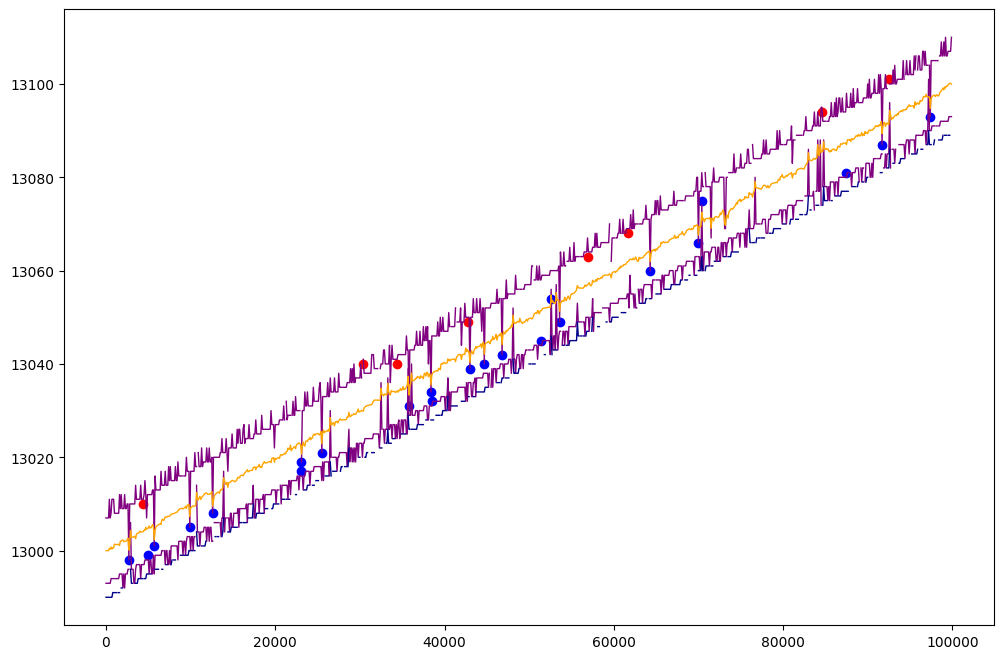

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(root_prices["timestamp"], root_prices["bid_price_1"], lw=1, color="purple")
plt.plot(root_prices["timestamp"], root_prices["bid_price_2"], lw=1, color="darkblue")
plt.plot(root_prices["timestamp"], root_prices["bid_price_3"], lw=1, color="red")
plt.plot(root_prices["timestamp"], root_prices["ask_price_1"], lw=1, color="purple")
#plt.plot(root_prices["timestamp"], root_prices["ask_price_2"], lw=1, color="darkblue")
#plt.plot(root_prices["timestamp"], root_prices["ask_price_3"], lw=1, color="red")
plt.plot(root_prices["timestamp"], root_prices["fair_value"], lw=1, color="orange")
plt.scatter(root_buys["timestamp"], root_buys["price"], color="blue")
plt.scatter(root_sells["timestamp"], root_sells["price"], color="red")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

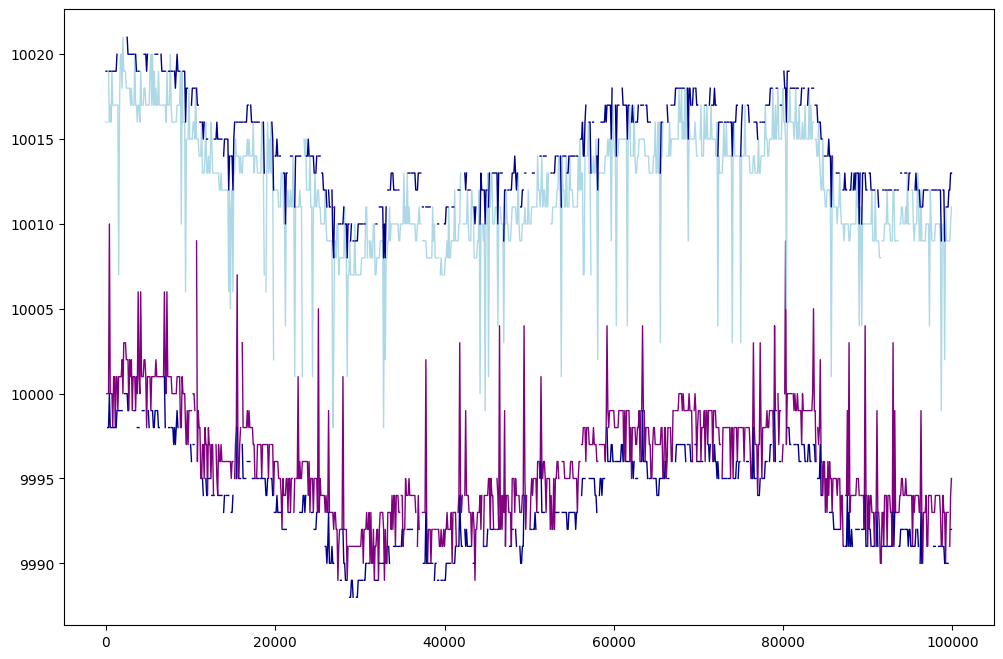

In [79]:
plt.figure(figsize=(12, 8))
plt.plot(ash_prices["timestamp"], ash_prices["bid_price_1"], lw=1, color="purple")
plt.plot(ash_prices["timestamp"], ash_prices["bid_price_2"], lw=1, color="darkblue")
plt.plot(ash_prices["timestamp"], ash_prices["bid_price_3"], lw=1, color="red")
plt.plot(ash_prices["timestamp"], ash_prices["ask_price_1"], lw=1, color="lightblue")
plt.plot(ash_prices["timestamp"], ash_prices["ask_price_2"], lw=1, color="darkblue")
plt.plot(ash_prices["timestamp"], ash_prices["ask_price_3"], lw=1, color="red")
#plt.scatter(ash_buys["timestamp"], ash_buys["price"], color="blue")
#plt.scatter(ash_sells["timestamp"], ash_sells["price"], color="red")
plt.show